<a href="https://colab.research.google.com/github/Plumz17/CVL_Assignment04/blob/main/CVL_Assignment04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Fourth Computer Vision Assignment - Analysis of Object Detection Algorithm - Anders Emmanuel Tan (24/541351/PA/22964)
Description: In this Assignment I will be Implementing two several Object Tracking Methods (Template Matching and Optical Flow) in order to track various objects in several videos which include:


*   Walking Person Tracking
*   Skating Person Tracking
*   Cup Tracking
*   Party-Occluded Person Tracking


Additionally, I will be manually implementing evaluation metrics in order to evaluate and analyze the performance of both methods.

For this assignment, i will be using an Object Tracking Benchmark (OTB) dataset from kaggle as can be seen in this link: (https://www.kaggle.com/datasets/zly1402875051/otb2015) and this a Video Tracking Dataset which can be seen in this link: (https://www.kaggle.com/datasets/kmader/videoobjecttracking). Since the files provided in the dataset are in the form of multiple .jpg files, we will also be providing a function that converts those into video file so we can illustrate the algorithm's performance (since videos are just sequences of frames).

You can see the output video and the input frames/groundtruth in the link below:
https://drive.google.com/drive/folders/1ILXAU1vHC6lpIB5q6f5s714T6wUmrhFv?usp=sharing
(and in the github submssion)

## 0. Setting Up
Description: For this first section, we will be preparing the frames that will later be processed. Since the uploaded files in Google Colab are only available in the runtime, I will be attaining those files by acquiring them from my mounted google drive folder (which contains a folder with all of the frames as well as a .txt file containing the information of the bounding boxes). Additionaly, we will also be importing the libaries that we will be using for this submission to import and process the frames. We will also be defining some helper functions to aid us in our implementation later (including one that'll combine every frame into a video)

### 0A. Importing the Files

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import Important Libraries
import cv2 # For Reading Image
import numpy as np # For Manipulating Numeric types
import matplotlib.pyplot as plt # For Showing Image
import math # For Math
import os # For managing files

#Loading File using their Filenames
filename_video_walk    = "/content/drive/MyDrive/CVL_Files/video_walk"
filename_video_walk_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_walk.txt"
filename_video_skating    = "/content/drive/MyDrive/CVL_Files/video_skating"
filename_video_skating_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_skating.txt"
filename_video_cup    = "/content/drive/MyDrive/CVL_Files/video_cup"
filename_video_cup_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_cup.txt"
filename_video_occlusion    = "/content/drive/MyDrive/CVL_Files/video_occlusion"
filename_video_occlusion_gt = "/content/drive/MyDrive/CVL_Files/groundtruth_occlusion.txt"

#Initialize output folder
os.makedirs("/content/output", exist_ok=True)

In [ ]:
def load_frames_from_folder(folder_path):
  # Get all filenames and sort them
  frame_files = sorted(os.listdir(folder_path))
  frames = []
  for file in frame_files:
    file_path = os.path.join(folder_path, file)

    # Read image
    img = cv2.imread(file_path)

    # Convert to grayscale for ease and append it to frames
    if img is not None:
      img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
      frames.append(img)

  return frames

In [ ]:
def load_ground_truth(gt_path, delimiter=","):
  gt = []
  with open(gt_path, 'r') as f:
    for line in f:
      # Dataset ground truth is tab seperated
      line = line.strip()
      values = [float(v) for v in line.split(delimiter) if v != '']
      # Each line is x, y, width, height
      gt.append(values[:4])
  return np.array(gt, dtype=np.float32)

frames_walk = load_frames_from_folder(filename_video_walk)
gt_boxes_walk = load_ground_truth(filename_video_walk_gt, "\t")
frames_skating = load_frames_from_folder(filename_video_skating)
gt_boxes_skating = load_ground_truth(filename_video_skating_gt, ",")
frames_cup = load_frames_from_folder(filename_video_cup)
gt_boxes_cup = load_ground_truth(filename_video_cup_gt, ",")
frames_occlusion = load_frames_from_folder(filename_video_occlusion)
gt_boxes_occlusion = load_ground_truth(filename_video_occlusion_gt, ",")

### 0B. Defining Helper Functions

In [ ]:
def show(img): # Helper function to show frame
  if len(img.shape) == 3:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.figure(figsize=(10,5))
  plt.subplot(1,2,1)
  plt.imshow(img, cmap='gray', vmin=0, vmax=255) #vmin and max to preserve original image's contrast
  plt.title("Original")
  plt.axis("off")
  plt.show()

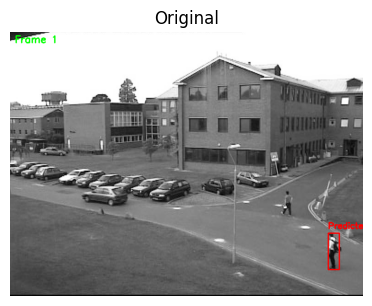

In [ ]:
def draw_ground_truth(frames, gt_boxes, frame_idx):
  frame = frames[frame_idx]
  # Change frame into BGR if it isn't already to draw colored box
  if len(frame.shape) == 2:
    annotated_frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
  else:
    annotated_frame = frame.copy()
  # Unpack the the gt_box
  x, y, w, h = [int(v) for v in gt_boxes[frame_idx]]

  cv2.rectangle(annotated_frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
  cv2.putText(annotated_frame, f"Frame {frame_idx+1}", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
  return annotated_frame

def draw_pred_box(frames, gt_boxes, pred_box, frame_idx):
  # Show GT box too
  annotated_frame = draw_ground_truth(frames, gt_boxes, frame_idx)
  # Unpack predicted box
  x, y, w, h = [int(v) for v in pred_box]

  # Draw predicted box in red
  cv2.rectangle(annotated_frame, (x, y), (x+w, y+h), (0, 0, 255), 2)
  cv2.putText(annotated_frame, "Predicted", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

  return annotated_frame

predicted_frame = draw_pred_box(frames_walk, gt_boxes_walk, gt_boxes_walk[0], frame_idx=0)

show(predicted_frame)

In [ ]:
#Helper Function to play the frames as a video
def save_frames_as_video(frames, filename, gt_boxes=None,output_path="/content", fps=30):
  h, w = frames[0].shape[:2]
  # Define video writer
  fourcc = cv2.VideoWriter_fourcc(*'mp4v')
  full_path = f"{output_path}/output/{filename}.mp4"
  out = cv2.VideoWriter(full_path, fourcc, fps, (w, h), isColor=True)
  for i, frame in enumerate(frames):
    if gt_boxes is not None:
      # Use the thre previous function
      out_frame = draw_ground_truth(frames, gt_boxes, i)
    else:
      out_frame = frame
    out.write(out_frame)
  out.release()

save_frames_as_video(frames_walk, "output_gt_walk", gt_boxes=gt_boxes_walk)
save_frames_as_video(frames_skating, "output_gt_skating", gt_boxes=gt_boxes_skating)
save_frames_as_video(frames_cup, "output_gt_cup", gt_boxes=gt_boxes_cup)
save_frames_as_video(frames_occlusion, "output_gt_occlusion", gt_boxes=gt_boxes_occlusion)

## 1. Template Matching
Description: For my implementation of Template Matching i will be using SSD (Sum of Squared Differences) as the similarity metric to calculate the similiar (or in this case, how different) the template image from the "patch" that the algorithm is checking. Moreover, instead of running the template matching algorithm every frame, we will be keeping track of the previous frames' predicted bounding box position and then comparing the previous bounding box with several candidate boxes within that search radius (this is done because pak wahyono uses template matching as a tracking algorithm not a detection algorithm in class). On top of that, we will also be calculating the IoU and error of the center points for every frame to measure the performance of our algorithm compared to the ground truth provided in the dataset. Finally, we will be calculating the average, the true positive rate, as well as plotting both metrics over time, so we can know precisely when the algorithm fails or suceeds.

### 1A. Template Matching Implementation

In [ ]:
#Helper Function to Extract a template from a given bounding box (first bounding box)
def extract_template(frame, bbox):
  x, y, w, h = [int(v) for v in bbox]
  return frame[y:y+h, x:x+w].copy()

In [ ]:
#Function to calculate sum of squared differences
def compute_ssd(template, patch):
    return np.sum((patch.astype(np.float32) - template.astype(np.float32)) ** 2)

In [ ]:
#Function to generate candidates from current bounding box
def generate_candidates(frame, current_box, search_radius, step):
  candidate_x, candidate_y, candidate_w, candidate_h = [int(v) for v in current_box]
  candidates = []
  frame_h, frame_w = frame.shape[:2]
  for dy in range(-search_radius, search_radius + 1, step):
    for dx in range(-search_radius, search_radius + 1, step):
      # Shift the current box by (dx, dy)
      new_x = candidate_x + dx
      new_y = candidate_y + dy
      if new_x < 0 or new_y < 0:
        continue
      if new_x + candidate_w > frame_w or new_y + candidate_h > frame_h:
        continue
      candidates.append((new_x, new_y, candidate_w, candidate_h))
  return candidates

In [ ]:
#Function to find the box with the lowest sum of squared differences (SSD)
def find_best_match(frame, template, candidates):
  best_score = float('inf')
  best_box = None
  for (candidate_x, candidate_y, candidate_w, candidate_h) in candidates:
    patch = frame[candidate_y:candidate_y+candidate_h, candidate_x:candidate_x+candidate_w]
    score = compute_ssd(template, patch)
    if score < best_score:
      best_score = score
      best_box = (candidate_x, candidate_y, candidate_w, candidate_h)
  return best_box

In [ ]:
def template_matching(frames, initial_box, search_radius=20, step=1):
  #Define template and first box as the first ground truth's bounding box
  template = extract_template(frames[0], initial_box)
  pred_boxes = [initial_box]
  current_box = initial_box
  #Find box with highest SSD with the template
  for frame in frames[1:]:
    candidates = generate_candidates(frame, current_box, search_radius, step)
    best_box = find_best_match(frame, template, candidates)
    pred_boxes.append(best_box)
    current_box = best_box
  return pred_boxes

In [ ]:
initial_box_walk = gt_boxes_walk[0]
pred_boxes_walk = template_matching(frames_walk, initial_box_walk, search_radius=20, step=1)

initial_box_skating = gt_boxes_skating[0]
pred_boxes_skating = template_matching(frames_skating, initial_box_skating, search_radius=20, step=1)

initial_box_cup = gt_boxes_cup[0]
pred_boxes_cup = template_matching(frames_cup, initial_box_cup, search_radius=20, step=1)

initial_box_occlusion = gt_boxes_occlusion[0]
pred_boxes_occlusion = template_matching(frames_occlusion, initial_box_occlusion, search_radius=20, step=1)

In [ ]:
#Annotate frames with predictions
annotated_frames_walk = []
for i, frame in enumerate(frames_walk):
  annotated_frames_walk.append(draw_pred_box(frames_walk, gt_boxes_walk, pred_boxes_walk[i], i))
#Export as Video
save_frames_as_video(annotated_frames_walk, "output_tm_walk")

#Annotate frames with predictions
annotated_frames_skating = []
for i, frame in enumerate(frames_skating):
  annotated_frames_skating.append(draw_pred_box(frames_skating, gt_boxes_skating, pred_boxes_skating[i], i))
#Export as Video
save_frames_as_video(annotated_frames_skating, "output_tm_skating")

#Annotate frames with predictions
annotated_frames_cup = []
for i, frame in enumerate(frames_cup):
  annotated_frames_cup.append(draw_pred_box(frames_cup, gt_boxes_cup, pred_boxes_cup[i], i))
#Export as Video
save_frames_as_video(annotated_frames_cup, "output_tm_cup")

#Annotate frames with predictions
annotated_frames_occlusion = []
for i, frame in enumerate(frames_occlusion):
  annotated_frames_occlusion.append(draw_pred_box(frames_occlusion, gt_boxes_occlusion, pred_boxes_occlusion[i], i))

#Export as Video
save_frames_as_video(annotated_frames_occlusion, "output_tm_occlusion")

### 1B. Template Matching Evaluation

In [ ]:
# A Helper Function that Computes the Intersection over Union
def compute_iou(boxa, boxb):
  xa, ya, wa, ha = boxa
  xb, yb, wb, hb = boxb
  xai = max(xa, xb)
  xbi = min(xa+wa, xb+wb)
  yai = max(ya, yb)
  ybi = min(ya+ha, yb+hb)
  inter = max(0, xbi - xai) * max(0, ybi - yai)
  union = wa * ha + wb * hb - inter
  if union > 0:
    return inter / union
  else:
    return 0.0

compute_iou(pred_boxes_walk[1], gt_boxes_walk[1])

np.float32(0.7006652)

In [ ]:
# A Helper Function that Computes the euclidean difference between two boxes' center
def compute_center_error(boxa, boxb):
  xa, ya, wa, ha = boxa
  xb, yb, wb, hb = boxb
  cx_a = xa + wa / 2
  cy_a = ya + ha / 2
  cx_b = xb + wb / 2
  cy_b = yb + hb / 2
  return math.sqrt((cx_a - cx_b) ** 2 + (cy_a - cy_b) ** 2)

compute_center_error(pred_boxes_walk[1], gt_boxes_walk[1])

1.5811388300841898

In [ ]:
# Calculate the IoU and the error of every frame
tm_ious_walk = [compute_iou(pred_boxes_walk[i], gt_boxes_walk[i]) for i in range(len(pred_boxes_walk))]
tm_center_errors_walk = [compute_center_error(pred_boxes_walk[i], gt_boxes_walk[i]) for i in range(len(pred_boxes_walk))]

tm_ious_skating = [compute_iou(pred_boxes_skating[i], gt_boxes_skating[i]) for i in range(len(pred_boxes_skating))]
tm_center_errors_skating = [compute_center_error(pred_boxes_skating[i], gt_boxes_skating[i]) for i in range(len(pred_boxes_skating))]

tm_ious_cup = [compute_iou(pred_boxes_cup[i], gt_boxes_cup[i]) for i in range(len(pred_boxes_cup))]
tm_center_errors_cup = [compute_center_error(pred_boxes_cup[i], gt_boxes_cup[i]) for i in range(len(pred_boxes_cup))]

tm_ious_occlusion = [compute_iou(pred_boxes_occlusion[i], gt_boxes_occlusion[i]) for i in range(len(pred_boxes_occlusion))]
tm_center_errors_occlusion = [compute_center_error(pred_boxes_occlusion[i], gt_boxes_occlusion[i]) for i in range(len(pred_boxes_occlusion))]

In [ ]:
# Calculate the average iou, true positive rate, and average error
for name, tm_ious, tm_center_errors in [
  ("Walk", tm_ious_walk, tm_center_errors_walk),
  ("Skating", tm_ious_skating, tm_center_errors_skating),
  ("Cup", tm_ious_cup, tm_center_errors_cup),
  ("Occlusion", tm_ious_occlusion, tm_center_errors_occlusion),
]:
  avg_iou = sum(tm_ious) / len(tm_ious)
  avg_center_error = sum(tm_center_errors) / len(tm_center_errors)
  true_positive_rate = sum(1 for iou in tm_ious if iou >= 0.5) / len(tm_ious)
  print(f"Template Matching ({name}) - Average IoU:", avg_iou)
  print(f"Template Matching ({name}) - True Positive Rate (Percentage of IoU >= 0.5):", true_positive_rate)
  print(f"Template Matching ({name}) - Average Center Point Error (px):", avg_center_error)

Template Matching (Walk) - Average IoU: 0.67786205
Template Matching (Walk) - True Positive Rate (Percentage of IoU >= 0.5): 0.844311377245509
Template Matching (Walk) - Average Center Point Error (px): 5.586318123414411
Template Matching (Skating) - Average IoU: 0.6049447
Template Matching (Skating) - True Positive Rate (Percentage of IoU >= 0.5): 0.75625
Template Matching (Skating) - Average Center Point Error (px): 12.58792835806212
Template Matching (Cup) - Average IoU: 0.4210379
Template Matching (Cup) - True Positive Rate (Percentage of IoU >= 0.5): 0.5945945945945946
Template Matching (Cup) - Average Center Point Error (px): 43.64995699672095
Template Matching (Occlusion) - Average IoU: 0.8517897
Template Matching (Occlusion) - True Positive Rate (Percentage of IoU >= 0.5): 0.9081967213114754
Template Matching (Occlusion) - Average Center Point Error (px): 3.0061594323774044


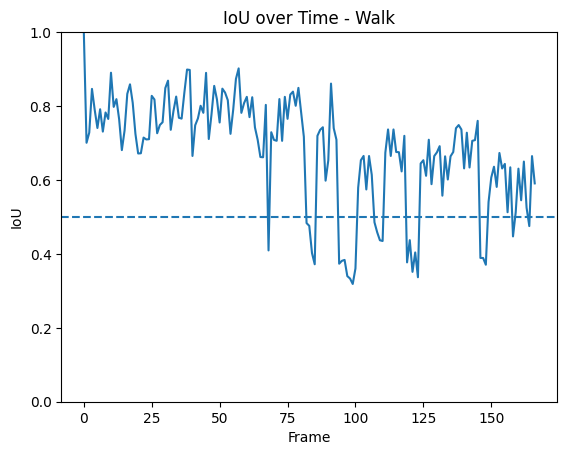

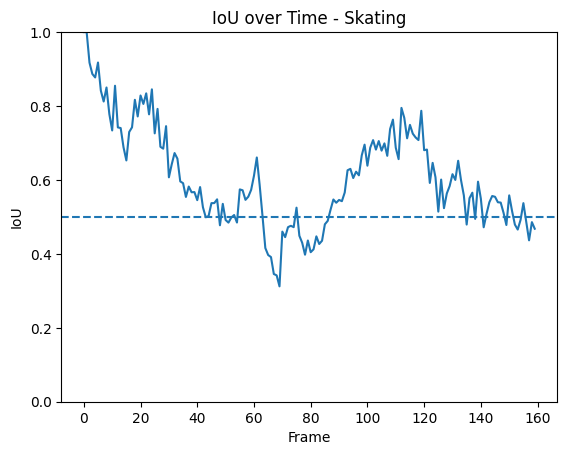

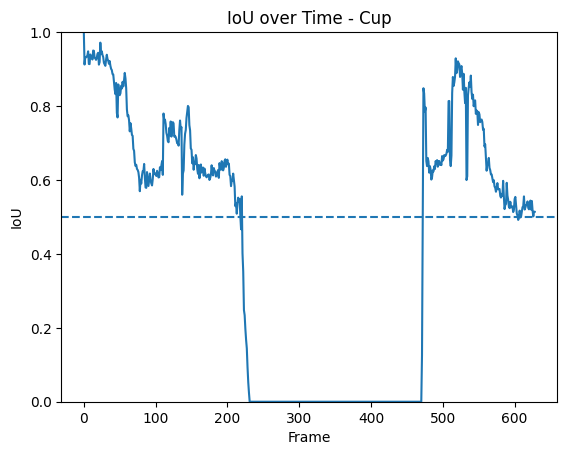

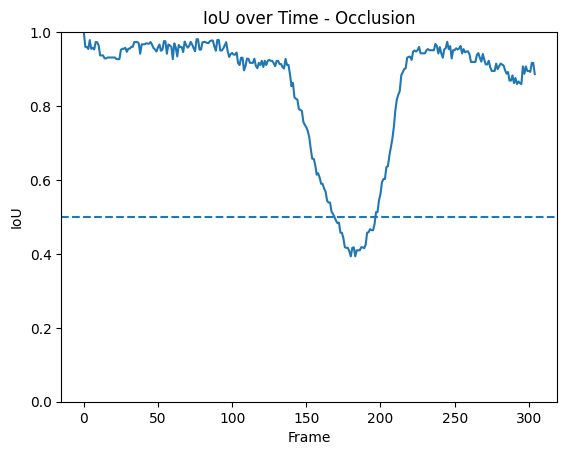

In [ ]:
#Show IoU over time
for name, tm_ious in [
  ("Walk", tm_ious_walk),
  ("Skating", tm_ious_skating),
  ("Cup", tm_ious_cup),
  ("Occlusion", tm_ious_occlusion),
]:
  plt.figure()
  plt.plot(tm_ious)
  plt.xlabel("Frame")
  plt.ylabel("IoU")
  plt.title(f"IoU over Time - {name}")
  plt.ylim(0, 1)
  plt.axhline(y=0.5, linestyle='--')
  plt.show()

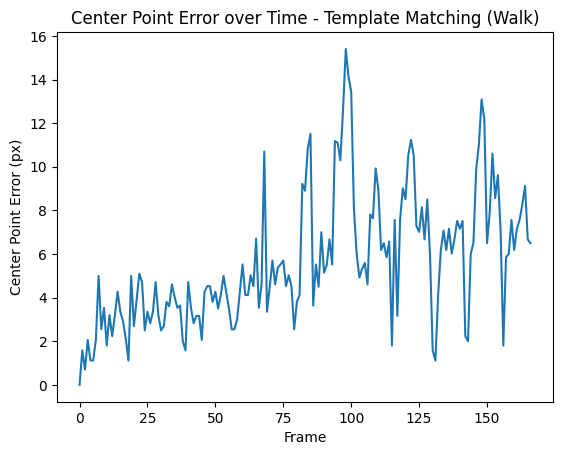

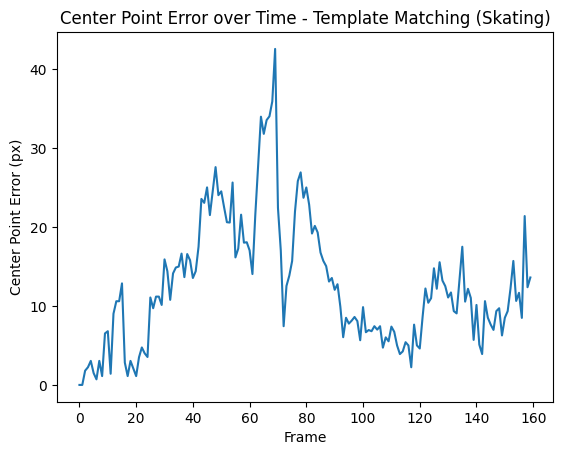

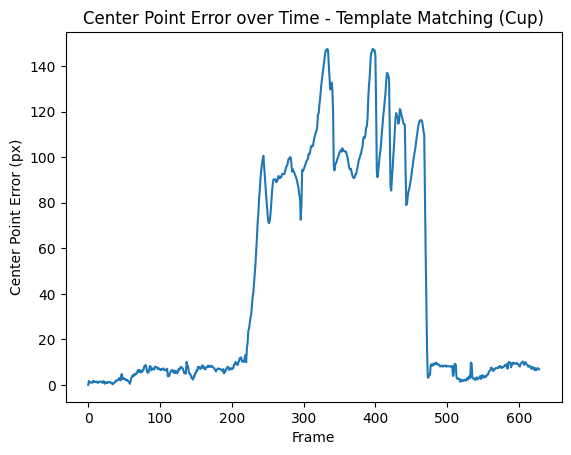

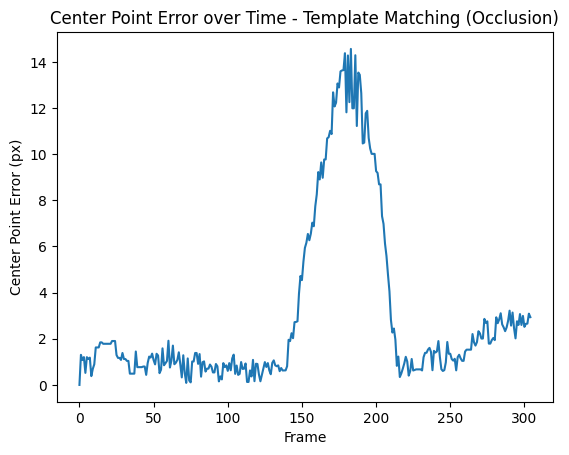

In [ ]:
#Show Error over time
for name, tm_center_errors in [
  ("Walk", tm_center_errors_walk),
  ("Skating", tm_center_errors_skating),
  ("Cup", tm_center_errors_cup),
  ("Occlusion", tm_center_errors_occlusion),
]:
  plt.figure()
  plt.plot(tm_center_errors)
  plt.xlabel("Frame")
  plt.ylabel("Center Point Error (px)")
  plt.title(f"Center Point Error over Time - Template Matching ({name})")
  plt.show()

### 1C. Template Matching Analysis
Analysis: From the evaluation results of the "Walk" dataset, we have extracted that the Average IoU of the predicted bounding box and ground truth is ~67.8% with a true positive rate of ~84.4% (meaning that 84.4% of the predicted bounding box meet the detection threshold, in this case 50%), the algorithm has also resulted in an average of about 5.5 pixel error of the bounding box's center.

Both of these data showcases that the template matching method resulted in a moderate performance in tracking the object (in this case a person). Additionally, if we plot the IoU and Center point error over time, we can see that the algorithm starts off strong in the first ~67 frames with the IoU consistently achieving above 0.8, suggesting the model handles the first few frames quite well, but it worsens after 70th frame. This might stem from the fact that my implementation of template matching assumes the object remains at a consistent scale throughout the sequence. Since the person in the video is walking further from the camera, the person itself will appear smaller as time passes, which makes the "patch" becomes less similar with the template as time marches on. Moreover, we can also observe that the performance dropped significantly during the 80th frame, that's likely due to another problem with template matching which is object occlusion. In the video, around the 80th frame, the person is occluded by a pole, which detrimentally affects the performance of the IoU.

A similar problem can be observed with the performance of the three other videos, for example, in the partial-occlusion dataset, the algorithm starts and ends with a high performance, only decreasing drastically during the section of the video where the person is partly occluded, since template matching is extremely sensitive to the object within the template. Additionally, we can also see that this algorithm also struggles in the cup dataset when it found a patch with a similar intensities/color/textures as the cup within the tracking area which made it track that object instead for a couple of frames which causes a dip in the IoU and a spike in the error. For the skating video, the algorithm consistently performs well.

In Future Implementations, we can solve some of these issues using image pyramids (where we compare the object with the templates of different resolutions and pick the best match) to handle scale variation, incorporating some sort of re-detection mechanism to recover from occlusion, and by periodically updating the template of the current predicted patch to prevent the algorithm from drifting to similar looking objects (as seen in the cup dataset)

## 2. Optical Flow
Description: For my implementation of optical flow, I will be using the Lukas-Kanade method, which is taught by Pak Wahyono during class. To do so, we can first compute the spatial and temporal image gradients (specifically Ix, Iy, and It) accross the full frame, then sample a (uniform) grid of points inside the current bounding box and estimate the optical flow vector (u,v) derived from the Lucas-Kanade equations. the median of all flow vectors per point is then used as the displacement of the bounding box. Same with template matching, we will be evaluating the algorithm's performance by using IoU and the error of the center point on every frame. We will be computing the average of these two metrics, and plotting each of them over time.

### 2A. Optical Flow Implementation

In [ ]:
# Compute the images' gradients
def compute_gradients(frame1, frame2):
  f1 = frame1.astype(np.float32)
  f2 = frame2.astype(np.float32)
  # Compute Intensity changes from left to right
  Ix = (np.roll(f1, -1, axis=1) - np.roll(f1, 1, axis=1) + np.roll(f2, -1, axis=1) - np.roll(f2, 1, axis=1)) / 4.0
  # Compute Intensity changes from top to bottom
  Iy = (np.roll(f1, -1, axis=0) - np.roll(f1, 1, axis=0) + np.roll(f2, -1, axis=0) - np.roll(f2, 1, axis=0)) / 4.0
  # Compute Intensity changes over time
  It = f2 - f1
  return Ix, Iy, It

In [ ]:
# Apply Lucas Kanade on a single point
def lucas_kanade_point(Ix, Iy, It, px, py, win=7):
  h, w = Ix.shape
  half = win
  # Clamp to image boundaries
  y0, y1 = max(0, py - half), min(h, py + half + 1)
  x0, x1 = max(0, px - half), min(w, px + half + 1)

  # Flatten the patch into 1D arrays
  ix = Ix[y0:y1, x0:x1].flatten()
  iy = Iy[y0:y1, x0:x1].flatten()
  it = It[y0:y1, x0:x1].flatten()

  # Compute components of A^T A and A^T b for least squares
  Sxx = np.sum(ix * ix)
  Syy = np.sum(iy * iy)
  Sxy = np.sum(ix * iy)
  Sxt = np.sum(ix * it)
  Syt = np.sum(iy * it)

  AtA = np.array([[Sxx, Sxy],
                [Sxy, Syy]])
  Atb = np.array([-Sxt, -Syt])

  # If det ≈ 0, the patch has no texture to track
  if abs(np.linalg.det(AtA)) < 1e-3:
    return 0.0, 0.0

  # Solve for t = (u, v) = AtA * Atb
  u, v = np.linalg.solve(AtA, Atb)
  return u, v

In [ ]:
def optical_flow_tracking(frames, initial_box, win=7, grid_step=5):
  box_x, box_y, box_w, box_h = [int(v) for v in initial_box]
  predicted_boxes = [(box_x, box_y, box_w, box_h)]  # Frame 0: use GT as starting position

  for i in range(1, len(frames)):
    previous_frame = frames[i - 1]
    current_frame  = frames[i]
    # Compute spatial (Ix, Iy) and temporal (It) gradients across the whole frame
    Ix, Iy, It = compute_gradients(previous_frame, current_frame)
    # Build a grid of evenly-spaced points inside the current bounding box
    point_xs = range(box_x + grid_step, box_x + box_w - grid_step, grid_step)
    point_ys = range(box_y + grid_step, box_y + box_h - grid_step, grid_step)
    # Estimate the flow vector (u, v) at each grid point using Lucas-Kanade
    flow_vectors = []
    for point_y in point_ys:
      for point_x in point_xs:
        u, v = lucas_kanade_point(Ix, Iy, It, point_x, point_y, win=win)
        flow_vectors.append((u, v))
    # Take the median across all points to get one reliable (u, v) for the whole box
    if len(flow_vectors) > 0:
      flows = np.array(flow_vectors)
      shift_x = np.median(flows[:, 0])
      shift_y = np.median(flows[:, 1])
    else:
      shift_x, shift_y = 0.0, 0.0
    # Shift the box by the median flow
    box_x = int(round(box_x + shift_x))
    box_y = int(round(box_y + shift_y))
    # Clamp the box so it doesn't go outside the frame boundaries
    frame_h, frame_w = current_frame.shape[:2]
    box_x = max(0, min(box_x, frame_w - box_w))
    box_y = max(0, min(box_y, frame_h - box_h))
    predicted_boxes.append((box_x, box_y, box_w, box_h))
  return predicted_boxes

In [ ]:
# Use Optical Flow Tracking on every video
of_pred_boxes_walk = optical_flow_tracking(frames_walk, gt_boxes_walk[0])
of_pred_boxes_skating = optical_flow_tracking(frames_skating, gt_boxes_skating[0])
of_pred_boxes_cup = optical_flow_tracking(frames_cup, gt_boxes_cup[0])
of_pred_boxes_occlusion = optical_flow_tracking(frames_occlusion, gt_boxes_occlusion[0])

In [ ]:
# Annotate and save as video
of_annotated_frames_walk = []
for i, frame in enumerate(frames_walk):
  of_annotated_frames_walk.append(draw_pred_box(frames_walk, gt_boxes_walk, of_pred_boxes_walk[i], i))
save_frames_as_video(of_annotated_frames_walk, "output_of_walk")

of_annotated_frames_skating = []
for i, frame in enumerate(frames_skating):
  of_annotated_frames_skating.append(draw_pred_box(frames_skating, gt_boxes_skating, of_pred_boxes_skating[i], i))
save_frames_as_video(of_annotated_frames_skating, "output_of_skating")

of_annotated_frames_cup = []
for i, frame in enumerate(frames_cup):
  of_annotated_frames_cup.append(draw_pred_box(frames_cup, gt_boxes_cup, of_pred_boxes_cup[i], i))
save_frames_as_video(of_annotated_frames_cup, "output_of_cup")

of_annotated_frames_occlusion = []
for i, frame in enumerate(frames_occlusion):
  of_annotated_frames_occlusion.append(draw_pred_box(frames_occlusion, gt_boxes_occlusion, of_pred_boxes_occlusion[i], i))
save_frames_as_video(of_annotated_frames_occlusion, "output_of_occlusion")

### 2B. Optical Flow Evaluation

In [ ]:
# Calculate the IoU and the error of every frame
of_ious_walk = [compute_iou(of_pred_boxes_walk[i], gt_boxes_walk[i]) for i in range(len(of_pred_boxes_walk))]
of_center_errors_walk = [compute_center_error(of_pred_boxes_walk[i], gt_boxes_walk[i]) for i in range(len(of_pred_boxes_walk))]

of_ious_skating = [compute_iou(of_pred_boxes_skating[i], gt_boxes_skating[i]) for i in range(len(of_pred_boxes_skating))]
of_center_errors_skating = [compute_center_error(of_pred_boxes_skating[i], gt_boxes_skating[i]) for i in range(len(of_pred_boxes_skating))]

of_ious_cup = [compute_iou(of_pred_boxes_cup[i], gt_boxes_cup[i]) for i in range(len(of_pred_boxes_cup))]
of_center_errors_cup = [compute_center_error(of_pred_boxes_cup[i], gt_boxes_cup[i]) for i in range(len(of_pred_boxes_cup))]

of_ious_occlusion = [compute_iou(of_pred_boxes_occlusion[i], gt_boxes_occlusion[i]) for i in range(len(of_pred_boxes_occlusion))]
of_center_errors_occlusion = [compute_center_error(of_pred_boxes_occlusion[i], gt_boxes_occlusion[i]) for i in range(len(of_pred_boxes_occlusion))]

In [ ]:
# Calculate the average iou, true positive rate, and average error
for name, of_ious, of_center_errors in [
  ("Walk", of_ious_walk, of_center_errors_walk),
  ("Skating", of_ious_skating, of_center_errors_skating),
  ("Cup", of_ious_cup, of_center_errors_cup),
  ("Occlusion", of_ious_occlusion, of_center_errors_occlusion),
]:
  of_avg_iou = sum(of_ious) / len(of_ious)
  of_avg_center_error = sum(of_center_errors) / len(of_center_errors)
  of_true_positive_rate = sum(1 for iou in of_ious if iou >= 0.5) / len(of_ious)
  print(f"Optical Flow ({name}) - Average IoU:", of_avg_iou)
  print(f"Optical Flow ({name}) - True Positive Rate (IoU >= 0.5):", of_true_positive_rate)
  print(f"Optical Flow ({name}) - Average Center Point Error (px):", of_avg_center_error)

Optical Flow (Walk) - Average IoU: 0.18372615
Optical Flow (Walk) - True Positive Rate (IoU >= 0.5): 0.17365269461077845
Optical Flow (Walk) - Average Center Point Error (px): 84.13735737745317
Optical Flow (Skating) - Average IoU: 0.61949563
Optical Flow (Skating) - True Positive Rate (IoU >= 0.5): 0.81875
Optical Flow (Skating) - Average Center Point Error (px): 9.492035363702493
Optical Flow (Cup) - Average IoU: 0.15824378
Optical Flow (Cup) - True Positive Rate (IoU >= 0.5): 0.17011128775834658
Optical Flow (Cup) - Average Center Point Error (px): 90.21769078902253
Optical Flow (Occlusion) - Average IoU: 0.73960316
Optical Flow (Occlusion) - True Positive Rate (IoU >= 0.5): 0.8295081967213115
Optical Flow (Occlusion) - Average Center Point Error (px): 7.9951123487719595


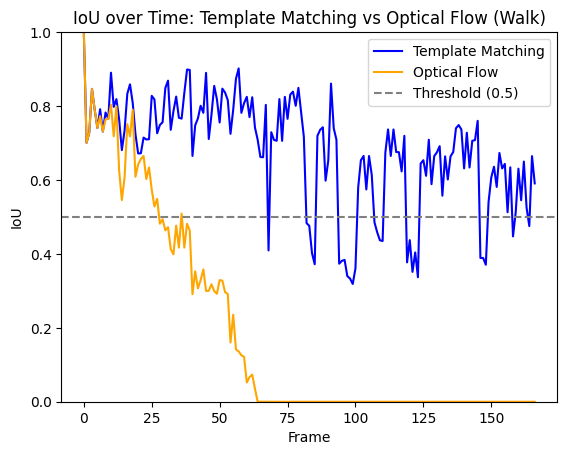

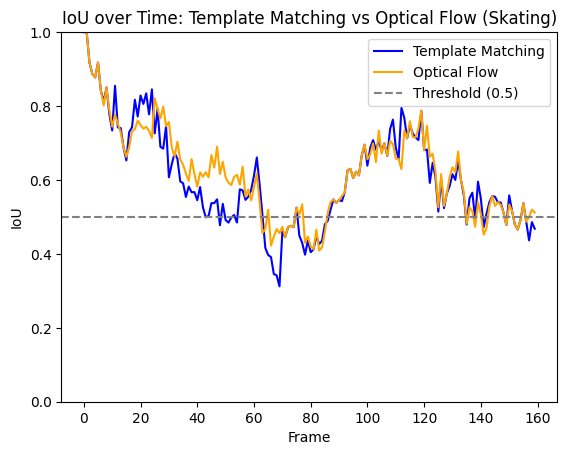

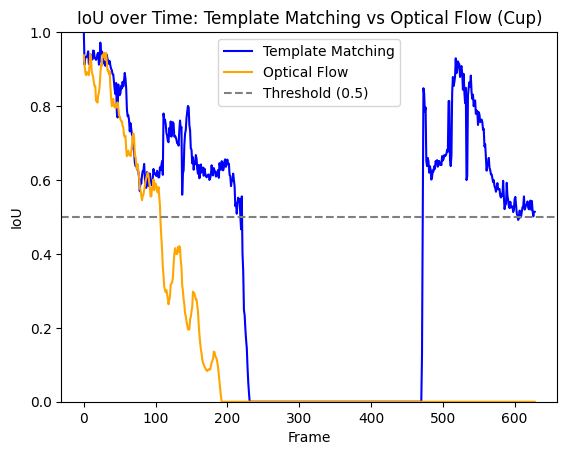

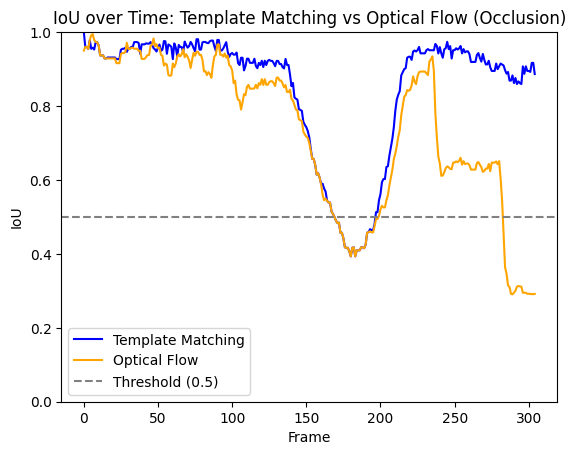

In [ ]:
# Plot the IoU over time
for name, tm_ious, of_ious in [
  ("Walk", tm_ious_walk, of_ious_walk),
  ("Skating", tm_ious_skating, of_ious_skating),
  ("Cup", tm_ious_cup, of_ious_cup),
  ("Occlusion", tm_ious_occlusion, of_ious_occlusion),
]:
  plt.figure()
  plt.plot(tm_ious, label="Template Matching", color="blue")
  plt.plot(of_ious, label="Optical Flow", color="orange")
  plt.xlabel("Frame")
  plt.ylabel("IoU")
  plt.title(f"IoU over Time: Template Matching vs Optical Flow ({name})")
  plt.ylim(0, 1)
  plt.axhline(y=0.5, linestyle='--', color='gray', label='Threshold (0.5)')
  plt.legend()
  plt.show()

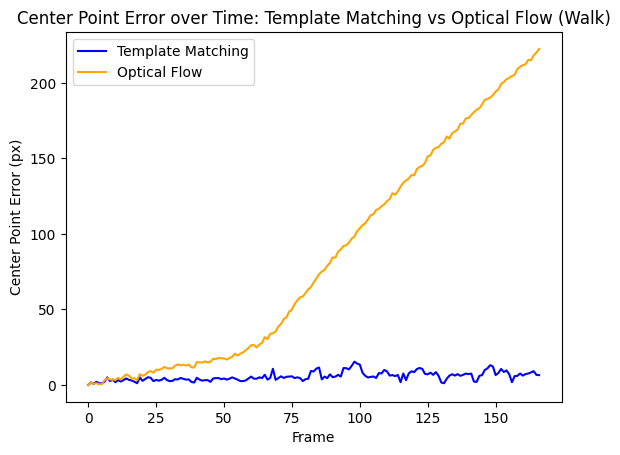

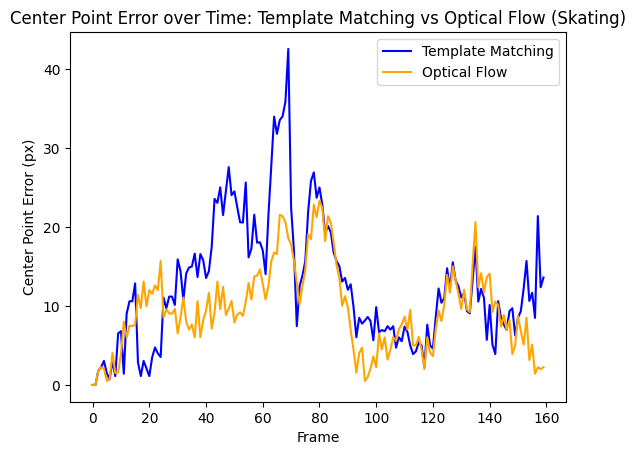

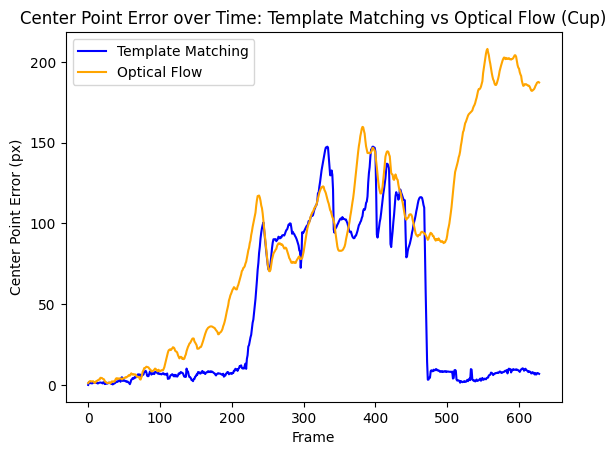

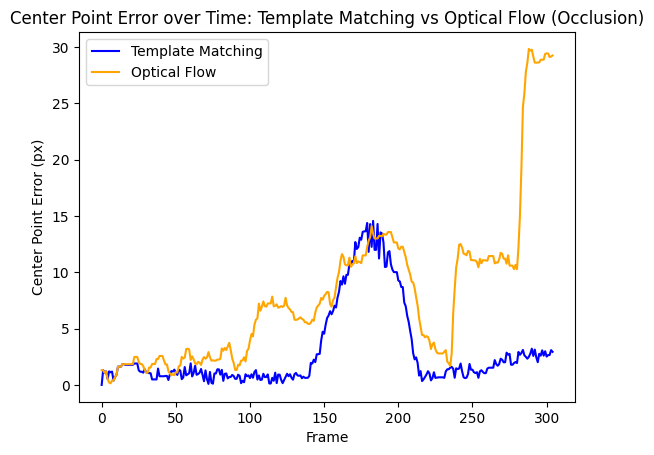

In [ ]:
# Plot the Error over time
for name, tm_center_errors, of_center_errors in [
  ("Walk", tm_center_errors_walk, of_center_errors_walk),
  ("Skating", tm_center_errors_skating, of_center_errors_skating),
  ("Cup", tm_center_errors_cup, of_center_errors_cup),
  ("Occlusion", tm_center_errors_occlusion, of_center_errors_occlusion),
]:
  plt.figure()
  plt.plot(tm_center_errors, label="Template Matching", color="blue")
  plt.plot(of_center_errors, label="Optical Flow", color="orange")
  plt.xlabel("Frame")
  plt.ylabel("Center Point Error (px)")
  plt.title(f"Center Point Error over Time: Template Matching vs Optical Flow ({name})")
  plt.legend()
  plt.show()

### 2C. Optical Flow Analysis
Analysis: Generalily Speaking, my Optical Flow implementation does worse than Template Matching in most of the videos. Whereas template matching performs consistenly in the four videos, Optical flow either does very well (and outperforms template matching) or fails almost completely, depending of the conditions of each of the videos.

For the skating video, the optical flow actually performs better than template matching, with a TP rate of ~82% (versus template matching's 75%). This probably stems from the skater's motion which is relatively smooth and directional, which is handled well be Lucas-Kande's Estimator. For the cup video, the tracker fails severly because of the cup's movement. In the video, the cup moves inconsistently, where the person holding the cup stops and starts moving the cup at unpredictably which confuses the algorithm  and makes it unstable. For the occlusion video, the algorithm performs moderately will with a 74% IoU and 83% TPR, it only deteriorates at the end due to the camera's erratic movement at the end of the video. Finally, for the walking sequence, the system fails due to accumulation of drift, because Lucas-Kanade is a frame-by-frame method without any correction of appearance, small errors in the estimated u and v will accumulate over time which makes the bounding box gradually steers off course from the target over time.

In future implementations, we can do a couple of things to overcome these weaknesses. For the accumulating drift problem, we can add a redetection mechanic when the IoU drops or the error reaches a certain threshold (perhaps using template matching to redetect where the object could be located). Second, we coulld use an adaptive bounding box size and make the algorithm account for changes in the objects' scale which is not currently handled in my implementation. On top of that, we can implement pyramidal Lucas-Kanade approach which can handle the erratic movements seen in the cup video.

In [ ]:
# Code to download the videos
# import shutil
# shutil.make_archive("/content/output_videos", "zip", "/content/output")

# from google.colab import files
# files.download("/content/output_videos.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>